# Dataset preparation

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [29]:
gates_counts = pd.read_csv('files/gates_counts.csv')
gates_counts

,NAME,ALL_GATES,USED_GATES,NONE,INVA,AND2,OR2,XOR2,NAND2,NOR2,XNOR2,TOTAL_AREA
0,mult8_cgp14ep_ep13107_wc0_2_rcam,320,319,0,0,167,48,104,0,0,0,990.86
1,mult8_cgp14ep_ep13107_wc0_rcam,320,320,0,0,168,48,104,0,0,0,993.20
2,mult8_cgp14ep_ep13107_wc0_wtmcla,490,381,0,2,203,66,110,0,0,0,1148.16
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,347,325,0,4,165,53,103,0,0,0,998.79
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,347,328,0,4,167,53,104,0,0,0,1008.16
...,...,...,...,...,...,...,...,...,...,...,...,...
24907,mult8_cgp14ep_ep65536_wc9_csamrca,320,299,0,0,155,47,96,0,0,1,927.61
24908,mult8_cgp14ep_ep65536_wc9_rcam,320,297,0,0,155,45,97,0,0,0,922.93
24909,mult8_cgp14ep_ep65536_wc9_wtmcla,490,336,0,0,178,58,100,0,0,0,1021.24
24910,mult8_cgp14ep_ep65536_wc9_wtmcsa,418,347,1,6,178,57,105,0,0,0,1050.75


In [30]:
json_data = pd.read_csv('files/json_data.csv')
json_data.columns = ['NAME', 'CELLS_JSON', 'SEED', 'MAE', 'WCE', 'WCRE']
json_data

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE
0,mult8_cgp14ep_ep13107_wc0_2_rcam,319,rcam,0.00000,0,0.000000
1,mult8_cgp14ep_ep13107_wc0_rcam,320,rcam,0.00000,0,0.000000
2,mult8_cgp14ep_ep13107_wc0_wtmcla,381,wtm_cla,0.00000,0,0.000000
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,325,csam_csa,35.63379,1000,252.631579
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,328,csam_csa,32.45898,1008,198.941799
...,...,...,...,...,...,...
24907,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000
24908,mult8_cgp14ep_ep65536_wc9_rcam,297,rcam,3.16406,9,100.000000
24909,mult8_cgp14ep_ep65536_wc9_wtmcla,336,wtm_cla,2.79688,9,350.000000
24910,mult8_cgp14ep_ep65536_wc9_wtmcsa,346,wtm_csa,3.15625,9,100.000000


In [31]:
df = pd.merge(json_data, gates_counts, left_on='NAME', right_on='NAME', how='inner')
df

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,ALL_GATES,USED_GATES,NONE,INVA,AND2,OR2,XOR2,NAND2,NOR2,XNOR2,TOTAL_AREA
0,mult8_cgp14ep_ep13107_wc0_2_rcam,319,rcam,0.00000,0,0.000000,320,319,0,0,167,48,104,0,0,0,990.86
1,mult8_cgp14ep_ep13107_wc0_rcam,320,rcam,0.00000,0,0.000000,320,320,0,0,168,48,104,0,0,0,993.20
2,mult8_cgp14ep_ep13107_wc0_wtmcla,381,wtm_cla,0.00000,0,0.000000,490,381,0,2,203,66,110,0,0,0,1148.16
3,mult8_cgp14ep_ep13107_wc1000_csamcsa,325,csam_csa,35.63379,1000,252.631579,347,325,0,4,165,53,103,0,0,0,998.79
4,mult8_cgp14ep_ep13107_wc1008_csamcsa,328,csam_csa,32.45898,1008,198.941799,347,328,0,4,167,53,104,0,0,0,1008.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24907,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000,320,299,0,0,155,47,96,0,0,1,927.61
24908,mult8_cgp14ep_ep65536_wc9_rcam,297,rcam,3.16406,9,100.000000,320,297,0,0,155,45,97,0,0,0,922.93
24909,mult8_cgp14ep_ep65536_wc9_wtmcla,336,wtm_cla,2.79688,9,350.000000,490,336,0,0,178,58,100,0,0,0,1021.24
24910,mult8_cgp14ep_ep65536_wc9_wtmcsa,346,wtm_csa,3.15625,9,100.000000,418,347,1,6,178,57,105,0,0,0,1050.75


In [32]:
diffs = df[df["USED_GATES"] != df["CELLS_JSON"]]
diffs 


,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,ALL_GATES,USED_GATES,NONE,INVA,AND2,OR2,XOR2,NAND2,NOR2,XNOR2,TOTAL_AREA
6,mult8_cgp14ep_ep13107_wc100_2_wtmcsa,351,wtm_csa,3.93945,100,52.173913,418,352,0,6,182,60,103,0,0,1,1062.44
8,mult8_cgp14ep_ep13107_wc100_3_wtmcsa,359,wtm_csa,10.37500,100,88.888889,418,360,0,6,187,59,107,1,0,0,1087.74
10,mult8_cgp14ep_ep13107_wc100_csamrca,306,csam_rca,7.21484,100,177.777778,320,305,0,0,157,47,100,0,0,1,951.05
13,mult8_cgp14ep_ep13107_wc100_wtmcsa,326,wtm_csa,7.48438,100,58.181818,418,338,3,5,171,55,103,1,0,0,1020.78
16,mult8_cgp14ep_ep13107_wc10240_2_csamcsa,326,csam_csa,631.61914,10240,199.650960,347,327,0,5,166,53,103,0,0,0,1002.53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24900,mult8_cgp14ep_ep65536_wc9_4_wtmcsa,347,wtm_csa,2.42188,9,100.000000,418,348,1,6,179,57,105,0,0,0,1053.09
24902,mult8_cgp14ep_ep65536_wc9_5_csamcsa,322,csam_csa,2.71556,9,100.000000,347,324,1,4,166,53,99,1,0,0,984.24
24904,mult8_cgp14ep_ep65536_wc9_5_wtmcsa,348,wtm_csa,2.96054,9,100.000000,418,349,1,6,179,58,105,0,0,0,1055.43
24907,mult8_cgp14ep_ep65536_wc9_csamrca,300,csam_rca,2.96094,9,100.000000,320,299,0,0,155,47,96,0,0,1,927.61


In [33]:
# Check 
df[df["NAME"] == 'mult8_cgp14ep_ep13107_wc1_csamcsa']
#df[df["CELLS_JSON"] == 411]

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,ALL_GATES,USED_GATES,NONE,INVA,AND2,OR2,XOR2,NAND2,NOR2,XNOR2,TOTAL_AREA
599,mult8_cgp14ep_ep13107_wc1_csamcsa,337,csam_csa,0.1875,1,100.0,347,337,0,4,175,53,105,0,0,0,1031.57


# Dataset analysis

In [34]:
df.dtypes

NAME           object
CELLS_JSON      int64
SEED           object
MAE           float64
WCE             int64
WCRE          float64
ALL_GATES       int64
USED_GATES      int64
NONE            int64
INVA            int64
AND2            int64
OR2             int64
XOR2            int64
NAND2           int64
NOR2            int64
XNOR2           int64
TOTAL_AREA    float64
dtype: object

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24912 entries, 0 to 24911
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   NAME        24912 non-null  object 
 1   CELLS_JSON  24912 non-null  int64  
 2   SEED        24912 non-null  object 
 3   MAE         24912 non-null  float64
 4   WCE         24912 non-null  int64  
 5   WCRE        24912 non-null  float64
 6   ALL_GATES   24912 non-null  int64  
 7   USED_GATES  24912 non-null  int64  
 8   NONE        24912 non-null  int64  
 9   INVA        24912 non-null  int64  
 10  AND2        24912 non-null  int64  
 11  OR2         24912 non-null  int64  
 12  XOR2        24912 non-null  int64  
 13  NAND2       24912 non-null  int64  
 14  NOR2        24912 non-null  int64  
 15  XNOR2       24912 non-null  int64  
 16  TOTAL_AREA  24912 non-null  float64
dtypes: float64(3), int64(12), object(2)
memory usage: 3.2+ MB


In [36]:
# Handling missing values
df.isnull().sum()

NAME          0
CELLS_JSON    0
SEED          0
MAE           0
WCE           0
WCRE          0
ALL_GATES     0
USED_GATES    0
NONE          0
INVA          0
AND2          0
OR2           0
XOR2          0
NAND2         0
NOR2          0
XNOR2         0
TOTAL_AREA    0
dtype: int64

In [37]:
# Check for duplicates
df.duplicated().sum()

0

In [38]:
# Show unique values in "SEED" column and their counts
df['SEED'].value_counts()

SEED
wtm_csa     4219
csam_csa    4203
wtm_cla     4201
csam_rca    4141
rcam        4078
wtm_rca     4070
Name: count, dtype: int64

In [39]:
# Summary statistics
df.describe()

,CELLS_JSON,MAE,WCE,WCRE,ALL_GATES,USED_GATES,NONE,INVA,AND2,OR2,XOR2,NAND2,NOR2,XNOR2,TOTAL_AREA
count,24912.000000,24912.000000,24912.000000,2.491200e+04,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000,24912.000000
mean,242.114684,767.358365,5281.799294,1.042052e+03,371.943762,243.629576,0.395713,1.510918,126.996548,44.080483,70.039860,0.212388,0.191313,0.202352,732.716354
std,86.323096,1690.113980,9346.992797,9.658196e+03,62.869819,85.360377,1.558631,2.298794,43.990553,12.264928,31.327567,0.928007,0.915309,0.900291,271.851051
min,0.000000,0.000000,0.000000,0.000000e+00,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,194.000000,15.512572,100.000000,1.000000e+02,320.000000,196.000000,0.000000,0.000000,102.000000,39.000000,50.000000,0.000000,0.000000,0.000000,573.630000
50%,272.000000,109.694745,860.000000,1.777778e+02,347.000000,273.000000,0.000000,0.000000,142.000000,47.000000,81.000000,0.000000,0.000000,0.000000,829.190000
75%,307.000000,646.749523,5672.000000,3.444444e+02,418.000000,307.000000,0.000000,4.000000,160.000000,52.000000,95.000000,0.000000,0.000000,0.000000,941.660000
max,381.000000,16256.250000,65025.000000,1.016700e+06,490.000000,381.000000,32.000000,31.000000,203.000000,69.000000,116.000000,29.000000,28.000000,32.000000,1148.160000


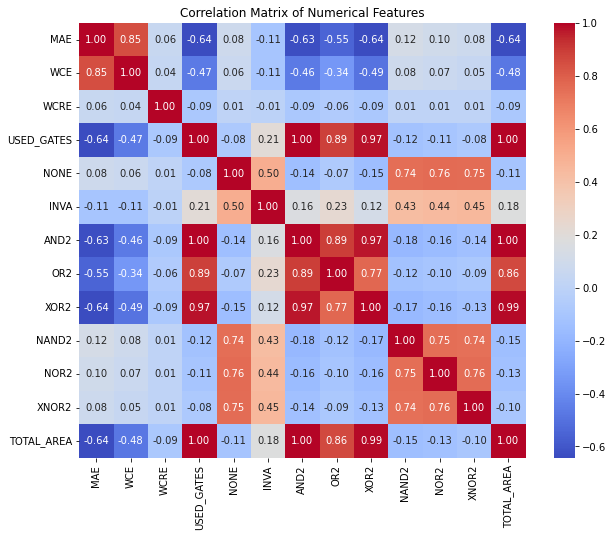

In [40]:
# Correlation matrix of numerical features
numerical_cols = ['MAE', 'WCE', 'WCRE', 'USED_GATES', 'NONE', 'INVA', 'AND2', 'OR2', 'XOR2', 'NAND2', 'NOR2', 'XNOR2', 'TOTAL_AREA']
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

array([[<Axes: xlabel='MAE', ylabel='MAE'>,
        <Axes: xlabel='WCE', ylabel='MAE'>,
        <Axes: xlabel='WCRE', ylabel='MAE'>,
        <Axes: xlabel='USED_GATES', ylabel='MAE'>,
        <Axes: xlabel='NONE', ylabel='MAE'>,
        <Axes: xlabel='INVA', ylabel='MAE'>,
        <Axes: xlabel='AND2', ylabel='MAE'>,
        <Axes: xlabel='OR2', ylabel='MAE'>,
        <Axes: xlabel='XOR2', ylabel='MAE'>,
        <Axes: xlabel='NAND2', ylabel='MAE'>,
        <Axes: xlabel='NOR2', ylabel='MAE'>,
        <Axes: xlabel='XNOR2', ylabel='MAE'>,
        <Axes: xlabel='TOTAL_AREA', ylabel='MAE'>],
       [<Axes: xlabel='MAE', ylabel='WCE'>,
        <Axes: xlabel='WCE', ylabel='WCE'>,
        <Axes: xlabel='WCRE', ylabel='WCE'>,
        <Axes: xlabel='USED_GATES', ylabel='WCE'>,
        <Axes: xlabel='NONE', ylabel='WCE'>,
        <Axes: xlabel='INVA', ylabel='WCE'>,
        <Axes: xlabel='AND2', ylabel='WCE'>,
        <Axes: xlabel='OR2', ylabel='WCE'>,
        <Axes: xlabel='XOR2', ylabel='WC

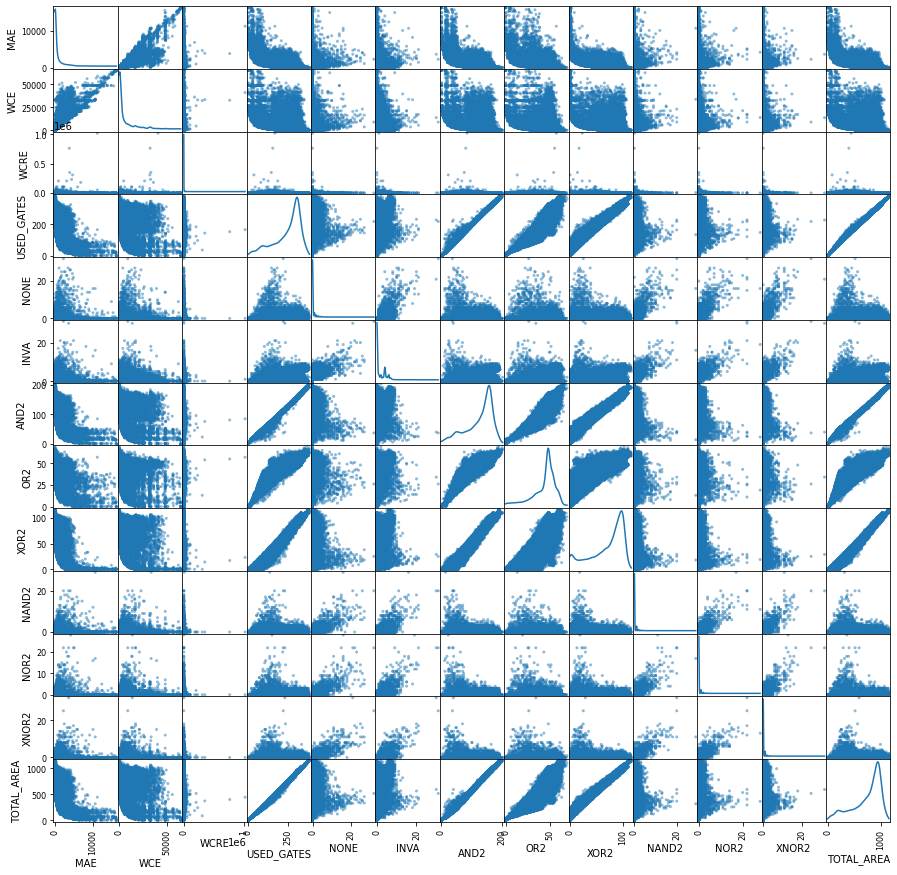

In [41]:
# Scatter matrix
pd.plotting.scatter_matrix(df[numerical_cols], figsize=(15, 15), diagonal='kde')


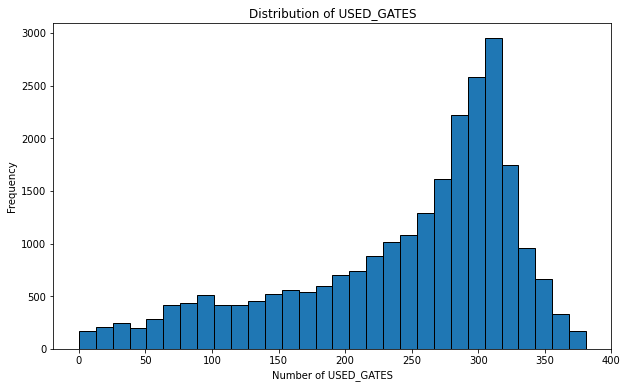

In [42]:
# Bar plot of USED_GATES
plt.figure(figsize=(10, 6))
plt.hist(df['USED_GATES'], bins=30, edgecolor='black')
plt.title('Distribution of USED_GATES')
plt.xlabel('Number of USED_GATES')
plt.ylabel('Frequency')
plt.show()

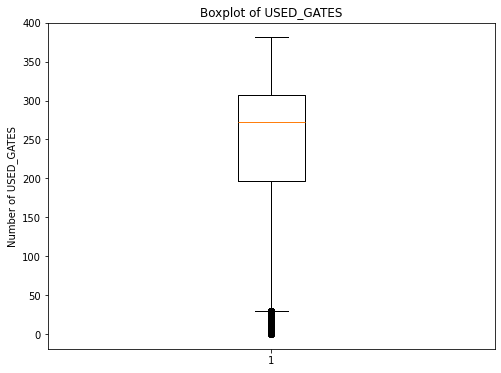

In [43]:
# Check for outliers in USED_GATES
plt.figure(figsize=(8, 6))
plt.boxplot(df['USED_GATES'], vert=True)    
plt.title('Boxplot of USED_GATES')
plt.ylabel('Number of USED_GATES')  
plt.show()

In [44]:
# Identify outliers using IQR
Q1 = df['USED_GATES'].quantile(0.25)
Q3 = df['USED_GATES'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['USED_GATES'] < (Q1 - 1.5 * IQR)) | (df['USED_GATES'] > (Q3 + 1.5 * IQR))]
outliers_lower_bound = Q1 - 1.5 * IQR
outliers_upper_bound = Q3 + 1.5 * IQR
outliers

,NAME,CELLS_JSON,SEED,MAE,WCE,WCRE,ALL_GATES,USED_GATES,NONE,INVA,AND2,OR2,XOR2,NAND2,NOR2,XNOR2,TOTAL_AREA
21202,mult8_cgp14ep_ep64716_wc12416_csamcsa,27,csam_csa,3343.76376,12416,101.041667,347,27,0,0,20,5,2,0,0,0,67.88
21255,mult8_cgp14ep_ep64716_wc13314_csamrca,29,csam_rca,2728.10559,13314,118.750000,320,29,0,0,20,4,5,0,0,0,79.61
21294,mult8_cgp14ep_ep64716_wc14720_wtmcsa,29,wtm_csa,3829.01300,14720,3200.000000,418,29,0,0,19,7,3,0,0,0,74.91
21377,mult8_cgp14ep_ep64716_wc16002_2_rcam,26,rcam,4490.47278,16002,6400.000000,320,26,0,0,19,5,2,0,0,0,65.54
21384,mult8_cgp14ep_ep64716_wc16002_wtmcsa,23,wtm_csa,4036.39685,16002,100.000000,418,23,0,0,18,3,2,0,0,0,58.52
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24588,mult8_cgp14ep_ep65536_wc65025_wtmrca,0,wtm_rca,16256.25000,65025,100.000000,333,0,0,0,0,0,0,0,0,0,0.00
24762,mult8_cgp14ep_ep65536_wc8433_wtmrca,28,wtm_rca,2131.78677,8433,1503.125000,333,28,0,0,16,5,7,0,0,0,81.97
24781,mult8_cgp14ep_ep65536_wc8721_csamrca,27,csam_rca,2262.09656,8721,137.548828,320,27,0,0,14,5,8,0,0,0,81.98
24799,mult8_cgp14ep_ep65536_wc8840_rcam,24,rcam,2501.96179,8840,3600.000000,320,24,0,0,14,4,6,0,0,0,70.26


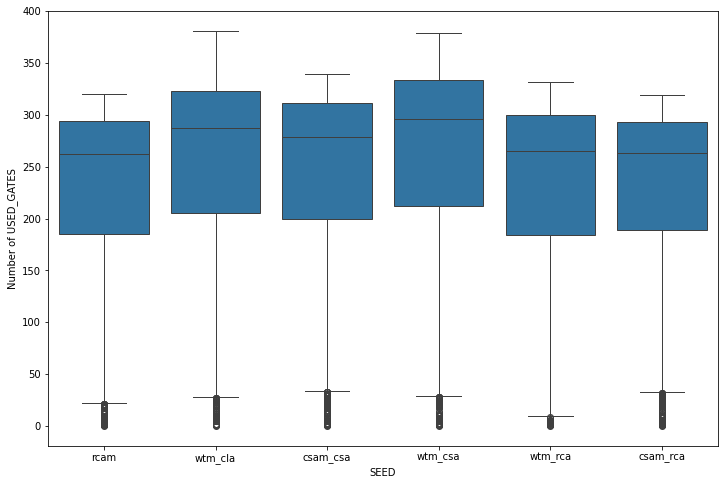

In [45]:
# Boxplot of USED_GATES considering SEED
plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='SEED', y='USED_GATES')
plt.xlabel('SEED')
plt.ylabel('Number of USED_GATES')
plt.show()

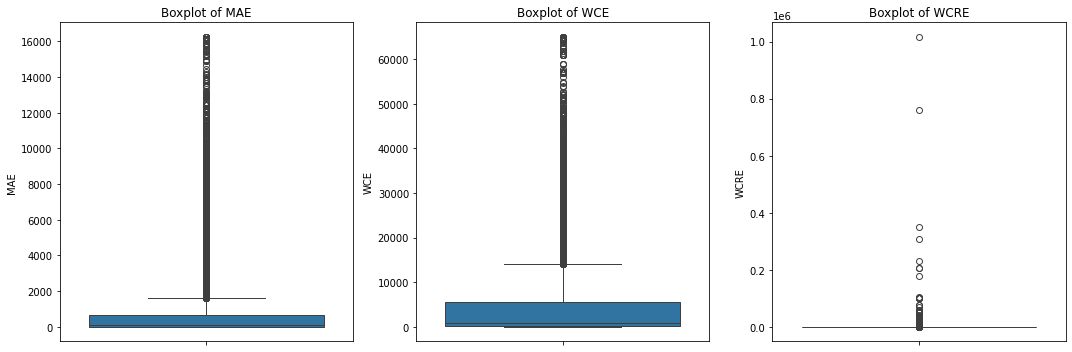

In [46]:
# Boxplot of MAE, WCE, WCRE
plt.figure(figsize=(15, 5)) 
plt.subplot(1, 3, 1)
sns.boxplot(y=df['MAE'])
plt.title('Boxplot of MAE')
plt.subplot(1, 3, 2)
sns.boxplot(y=df['WCE'])    
plt.title('Boxplot of WCE')
plt.subplot(1, 3, 3)
sns.boxplot(y=df['WCRE'])    
plt.title('Boxplot of WCRE')    
plt.tight_layout()
plt.show()

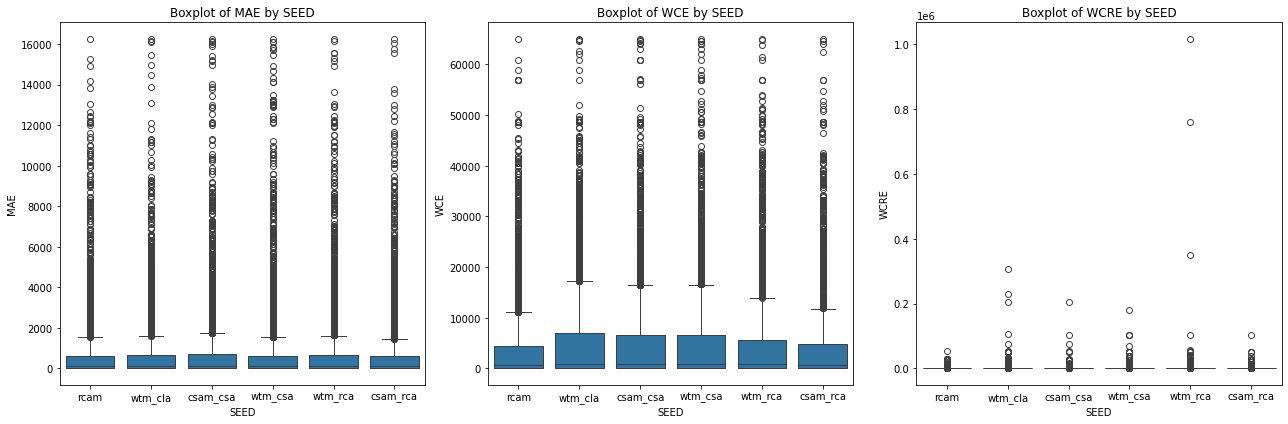

In [47]:
# Boxplot of MAE, WCE, WCRE considering SEED
plt.figure(figsize=(18, 6)) 
plt.subplot(1, 3, 1)
sns.boxplot(data=df, x='SEED', y='MAE')
plt.title('Boxplot of MAE by SEED')
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='SEED', y='WCE')
plt.title('Boxplot of WCE by SEED')
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='SEED', y='WCRE')
plt.title('Boxplot of WCRE by SEED')
plt.tight_layout()
plt.show()

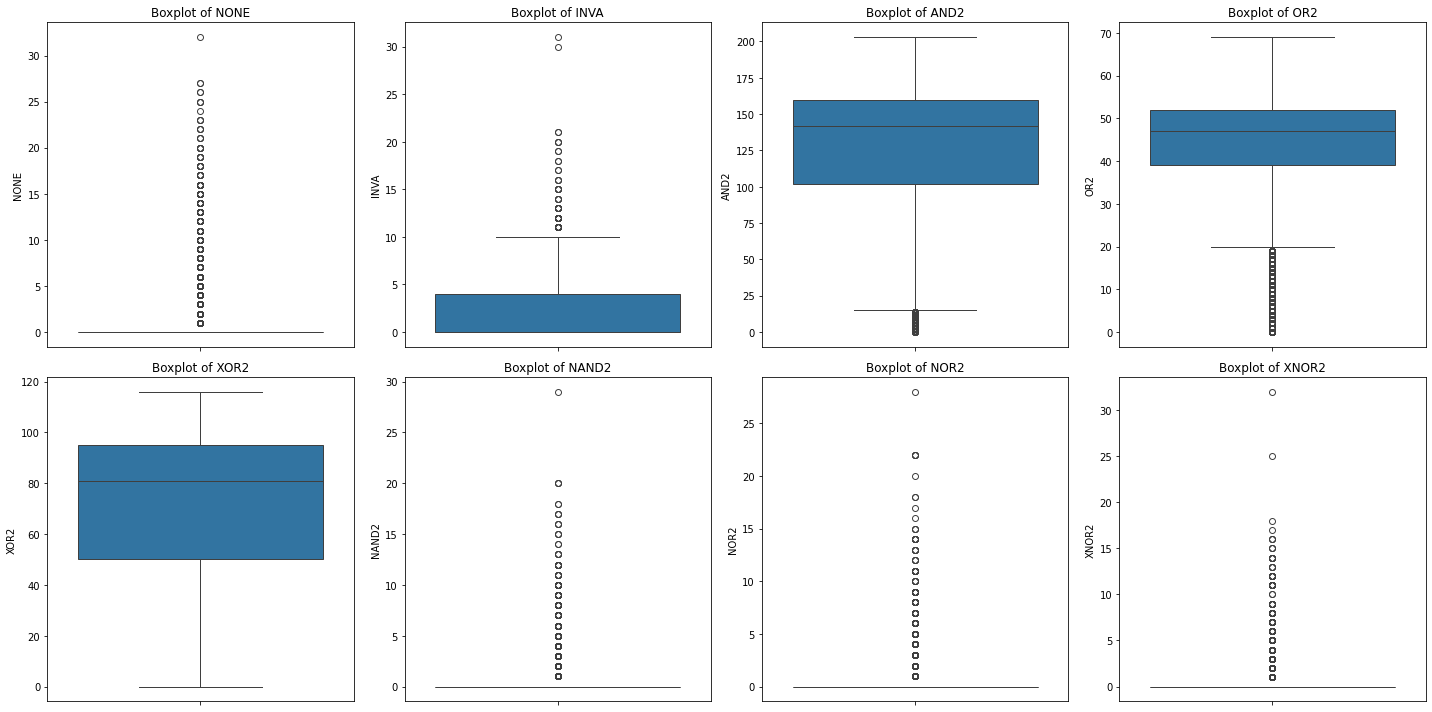

In [48]:
# Boxplot of NONE, INVA, AND2, OR2, XOR2, NAND2, NOR2, XNOR2
plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
sns.boxplot(y=df['NONE'])
plt.title('Boxplot of NONE')
plt.subplot(2, 4, 2)
sns.boxplot(y=df['INVA'])
plt.title('Boxplot of INVA')
plt.subplot(2, 4, 3)
sns.boxplot(y=df['AND2'])
plt.title('Boxplot of AND2')
plt.subplot(2, 4, 4)
sns.boxplot(y=df['OR2'])
plt.title('Boxplot of OR2')
plt.subplot(2, 4, 5)
sns.boxplot(y=df['XOR2'])
plt.title('Boxplot of XOR2')
plt.subplot(2, 4, 6)
sns.boxplot(y=df['NAND2'])
plt.title('Boxplot of NAND2')
plt.subplot(2, 4, 7)
sns.boxplot(y=df['NOR2'])
plt.title('Boxplot of NOR2')
plt.subplot(2, 4, 8)
sns.boxplot(y=df['XNOR2'])
plt.title('Boxplot of XNOR2')
plt.tight_layout()
plt.show()

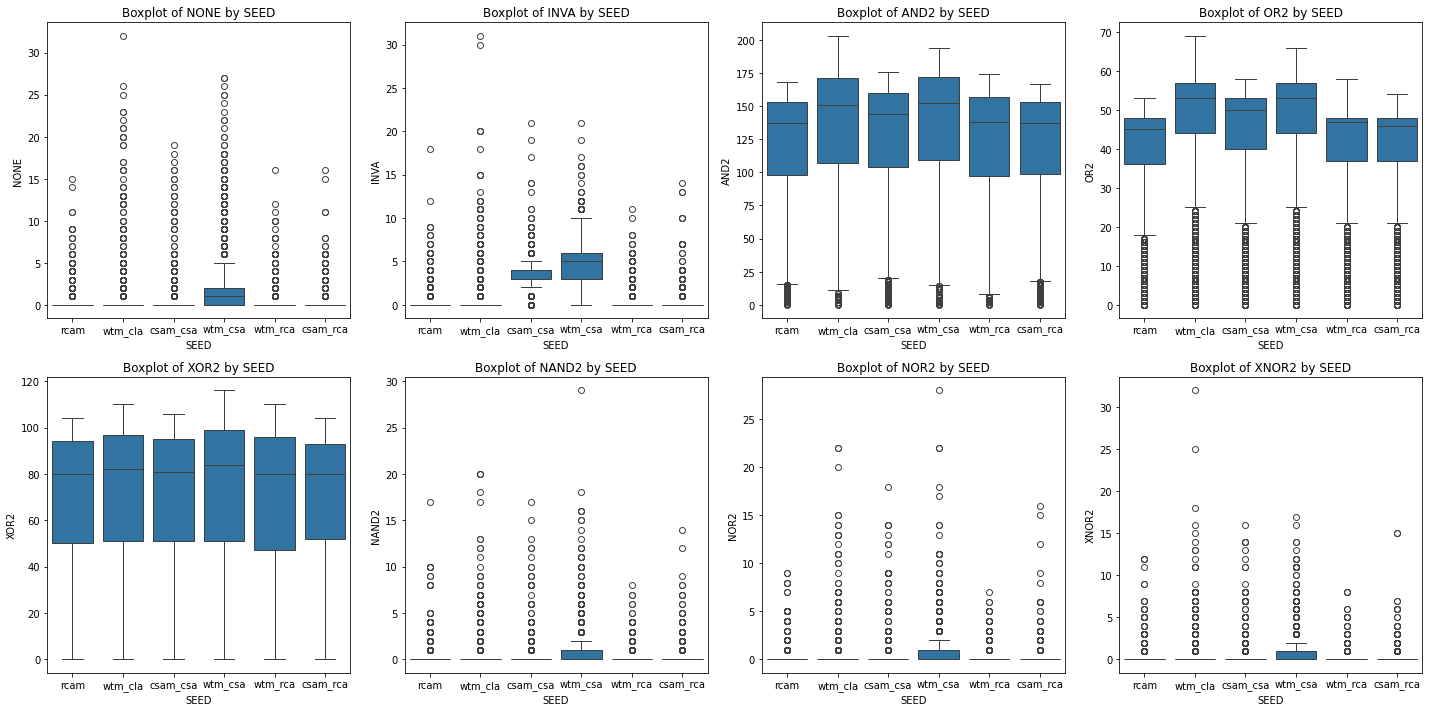

In [49]:
# Boxplot of NONE, INVA, AND2, OR2, XOR2, NAND2, NOR2, XNOR2 considering SEED
plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
sns.boxplot(data=df, x='SEED', y='NONE')
plt.title('Boxplot of NONE by SEED')
plt.subplot(2, 4, 2)
sns.boxplot(data=df, x='SEED', y='INVA')
plt.title('Boxplot of INVA by SEED')
plt.subplot(2, 4, 3)
sns.boxplot(data=df, x='SEED', y='AND2')
plt.title('Boxplot of AND2 by SEED')
plt.subplot(2, 4, 4)
sns.boxplot(data=df, x='SEED', y='OR2')
plt.title('Boxplot of OR2 by SEED')
plt.subplot(2, 4, 5)
sns.boxplot(data=df, x='SEED', y='XOR2')
plt.title('Boxplot of XOR2 by SEED')
plt.subplot(2, 4, 6)
sns.boxplot(data=df, x='SEED', y='NAND2')
plt.title('Boxplot of NAND2 by SEED')
plt.subplot(2, 4, 7)
sns.boxplot(data=df, x='SEED', y='NOR2')
plt.title('Boxplot of NOR2 by SEED')
plt.subplot(2, 4, 8)
sns.boxplot(data=df, x='SEED', y='XNOR2')
plt.title('Boxplot of XNOR2 by SEED')
plt.tight_layout()
plt.show()

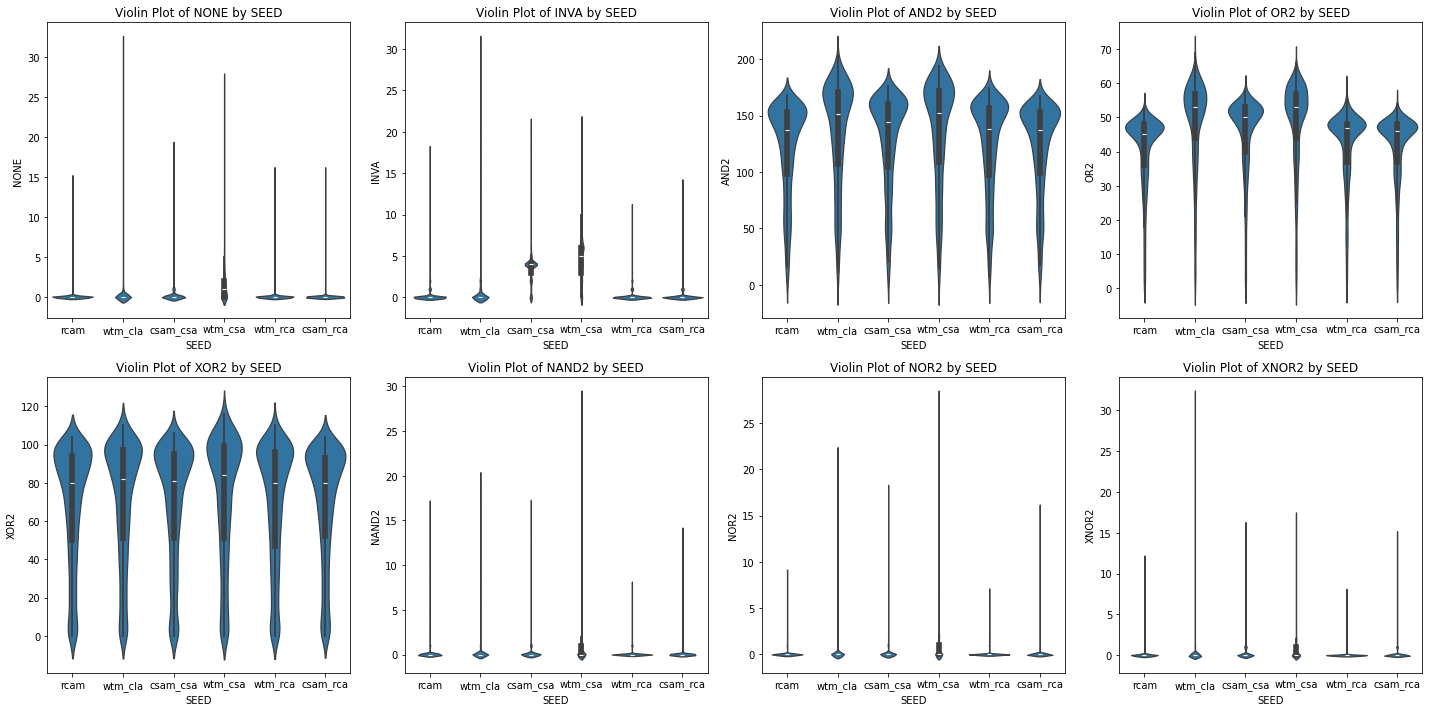

In [50]:
# Violin plots of NONE, INVA, AND2, OR2, XOR2, NAND2, NOR2, XNOR2 by SEED
plt.figure(figsize=(20, 10))
plt.subplot(2, 4, 1)
sns.violinplot(data=df, x='SEED', y='NONE')
plt.title('Violin Plot of NONE by SEED')
plt.subplot(2, 4, 2)
sns.violinplot(data=df, x='SEED', y='INVA')
plt.title('Violin Plot of INVA by SEED')
plt.subplot(2, 4, 3)
sns.violinplot(data=df, x='SEED', y='AND2')
plt.title('Violin Plot of AND2 by SEED')
plt.subplot(2, 4, 4)
sns.violinplot(data=df, x='SEED', y='OR2')
plt.title('Violin Plot of OR2 by SEED')
plt.subplot(2, 4, 5)
sns.violinplot(data=df, x='SEED', y='XOR2')
plt.title('Violin Plot of XOR2 by SEED')
plt.subplot(2, 4, 6)
sns.violinplot(data=df, x='SEED', y='NAND2')   
plt.title('Violin Plot of NAND2 by SEED')
plt.subplot(2, 4, 7)
sns.violinplot(data=df, x='SEED', y='NOR2')
plt.title('Violin Plot of NOR2 by SEED')
plt.subplot(2, 4, 8)
sns.violinplot(data=df, x='SEED', y='XNOR2')
plt.title('Violin Plot of XNOR2 by SEED')
plt.tight_layout()  


C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwargs)
C:\Users\nivan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\seaborn\axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make axes height small enough to accommodate all axes decorations.
  self._figure.tight_layout(*args, **kwa

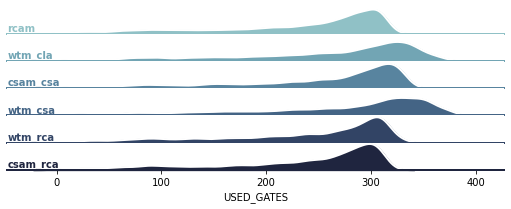

In [51]:
# Ridgeline plot of USED_GATES by SEED
pal = sns.cubehelix_palette(len(df['SEED'].unique()), rot=-.25, light=.7)
g = sns.FacetGrid(df, row="SEED", hue="SEED", aspect=15, height=0.5, palette=pal)
g.map(sns.kdeplot, "USED_GATES", bw_adjust=0.5, clip_on=False, fill=True, alpha=1, linewidth=1.5)
g.map(sns.kdeplot, "USED_GATES", bw_adjust=0.5, clip_on=False, color="w", lw=2)
g.refline(y=0, linestyle="-", color=None, lw=2, clip_on=False)

def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes) 
    
g.map(label, "USED_GATES")

g.figure.subplots_adjust(hspace=-0.00000001)
g.set_titles("")
g.set(yticks=[], ylabel="")
g.despine(bottom=True, left=True)
plt.show()

# Gates usage analysis

In [52]:
# POSSIBLE NEXT STEPS:
# classification of seed based on everything else
# analyse multipliers with very small number of used gates
# analyze multipliers with very small WCE/MAE/WCRE
# analyze multipliers with very small error and very small number of used gates


